# NOAA Mauna Loa CO2

## What this is

The longest continuous record of atmospheric carbon dioxide, measured at the Mauna Loa Observatory
in Hawaii since 1958 and published by NOAA's Global Monitoring Laboratory. This project uses it as
the observed baseline the IPCC scenario projections are anchored to, so a projected level starts
from a measured number rather than a modeled one.

## Provenance

These are the fields of the `CO2` declaration in `climate_risk/data/co2.py`, which is what `fetch`
reads. Check that file rather than this page if the two ever disagree.

In [1]:
import dataclasses

from IPython.display import Markdown

from climate_risk.data.co2 import CO2

declared = {
    "publisher": "NOAA Global Monitoring Laboratory, with Scripps Institution of Oceanography"
} | dataclasses.asdict(CO2)

rows = [f"| {field} | {value} |" for field, value in declared.items()]

Markdown("\n".join(["| Field | Value |", "|---|---|", *rows]))

| Field | Value |
|---|---|
| publisher | NOAA Global Monitoring Laboratory, with Scripps Institution of Oceanography |
| url | https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_mlo.csv |
| filename | co2_mm_mlo.csv |
| license | public domain (U.S. Government work, 17 U.S.C. 105) |
| citation | Lan, X., NOAA Global Monitoring Laboratory (https://gml.noaa.gov/ccgg/trends/) and Keeling, R., Scripps Institution of Oceanography. Mauna Loa monthly mean CO2. |
| retrieved | 2026-09-14 |

## Loading it

Every loader takes a cache directory and resolves nothing from the environment, so any directory
works. This page uses one named `data` in the working directory. The first call downloads the file
and every later one reads the cached copy.

In [2]:
import logging

from pathlib import Path

import matplotlib.pyplot as plt

import climate_risk as cr

from climate_risk.plotting import PALETTE, configure_plot_style

configure_plot_style(add_grid=True)

# The package installs an INFO handler when nothing else has, and a cache hit logs a line.
logging.getLogger("climate_risk").setLevel(logging.WARNING)

In [3]:
cache_dir = Path("data")

co2 = cr.load_co2_data(cache_dir)

co2_mm_mlo.csv:   0%|          | 0.00/38.7k [00:00<?, ?B/s]

## What you get

A polars frame. Which of polars and pandas a loader returns varies across this package, so it is
worth checking per loader. The column types are in the table header.

In [4]:
co2.head()

Date,co2
date,f64
1959-01-01,315.981667
1960-01-01,316.908333
1961-01-01,317.643333
1962-01-01,318.453333
1963-01-01,318.9925


## Units

| Column | Unit |
|---|---|
| `Date` | first day of the year the mean covers |
| `co2` | parts per million, as a mole fraction in dry air |

The published file states the mole fraction in the header the loader skips.

## Coverage

`describe` answers the span and the spread in one call, computed from the frame you just loaded, so
it cannot go stale when NOAA extends the record. The `Date` column carries the first and last year
the record covers.

In [5]:
co2.describe()

statistic,Date,co2
str,str,f64
"""count""","""67""",67.0
"""null_count""","""0""",0.0
"""mean""","""1992-01-01 08:57:18.805970""",361.251555
"""std""",null,32.899604
"""min""","""1959-01-01""",315.981667
"""25%""","""1976-01-01""",332.025833
"""50%""","""1992-01-01""",356.545
"""75%""","""2009-01-01""",387.6425
"""max""","""2025-01-01""",427.349167


## A plot

The Keeling curve. `load_co2_data` averages the published months over each period and defaults to
annual; ask for `frequency="monthly"` and the seasonal sawtooth comes with it.


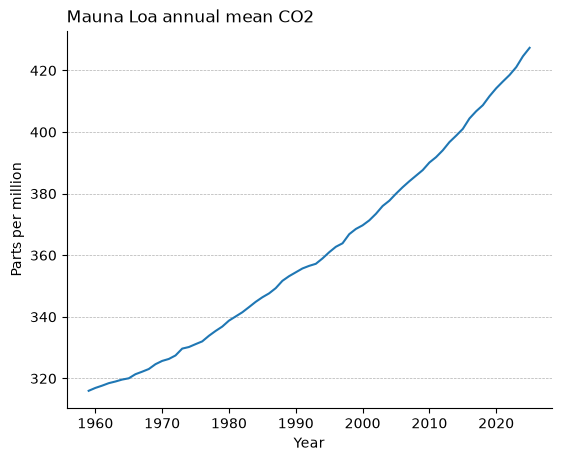

In [6]:
figure, axis = plt.subplots(figsize=(5.5, 4.5))
axis.plot(co2["Date"], co2["co2"], color=PALETTE["primary"])
axis.set_title("Mauna Loa annual mean CO2", loc="left")
axis.set_xlabel("Year")
axis.set_ylabel("Parts per million")

plt.show()

## Gotchas

*The site is not always Mauna Loa.* The 2022 eruption suspended measurements from November 2022
until July 2023, and the observations covering that gap were taken at Maunakea, about 21 miles
north. The published file says so in its header. The loaded frame does not, so a discontinuity
around 2023 is a change of instrument site and not of the atmosphere.

*The publisher's other columns are dropped.* The CSV carries `deseasonalized`, `ndays`, `sdev` and
`unc` alongside `average`, and `transform_co2` keeps only the average. Read `co2_mm_mlo.csv` out of
the cache directly if you need the rest.

*The monthly series carries a seasonal cycle.* Northern-hemisphere vegetation draws down about
6 ppm each summer and releases it each winter. At monthly resolution that cycle is in `co2`, and a
regressor built from it competes with any seasonal term in a model. NOAA's `deseasonalized` column
is the series with the cycle fitted out.

*`Date` is not a measurement date.* It is the first day of the period the mean covers, and it exists
so this frame joins onto the other series. Nothing was measured on that day in particular.

*There is no country dimension.* This is one global series, which makes it the exception among the
sources here. It broadcasts across countries rather than joining on an ISO code.

*The record ends behind today.* A period appears only once every month of it is published, so at
annual resolution the last row is the last complete year.

*The file is mostly not data.* Forty lines of license and methodology sit above the header
row, which is what `CO2_HEADER_ROW` in `climate_risk/data/co2.py` skips. Opening the CSV in a
spreadsheet shows the notes, not the table.